# Notebook 1: Hồi quy Tuyến Tính

## Đọc dữ liệu

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import time
from utils import (
    load_bike_data,
    load_registry,
    evaluate_model,
    plot_sklearn_learning_curve_wrapper,
    plot_learning_curve_data_size,
)

(
    train_df,
    features_to_drop,
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    X_test_scaled,
    y_test,
    X_train_b,
    X_val_b,
    X_test_b,
) = load_bike_data()

X_train_scaled_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_val_scaled_b = np.c_[np.ones((X_val_scaled.shape[0], 1)), X_val_scaled]
X_test_scaled_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

## 1. Hồi quy Tuyến Tính (Thuần Numpy)
### 1.1 Normal Equations

[Normal Equations OLS] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 17711.93 ± 9423.90
  - CV_RMSE (Mean ± Std): 128.49 ± 34.69
  - CV_MAE (Mean ± Std): 99.67 ± 29.57
  - CV_R2 (Mean ± Std): 0.1664 ± 0.2959
  - Val MSE: 33622.1540
  - Val RMSE: 183.3634
  - Val MAE: 148.9251
  - Val R2: 0.2983
  - Test MSE: 33590.7693
  - Test RMSE: 183.2778
  - Test MAE: 138.2918
  - Test R2: 0.3090


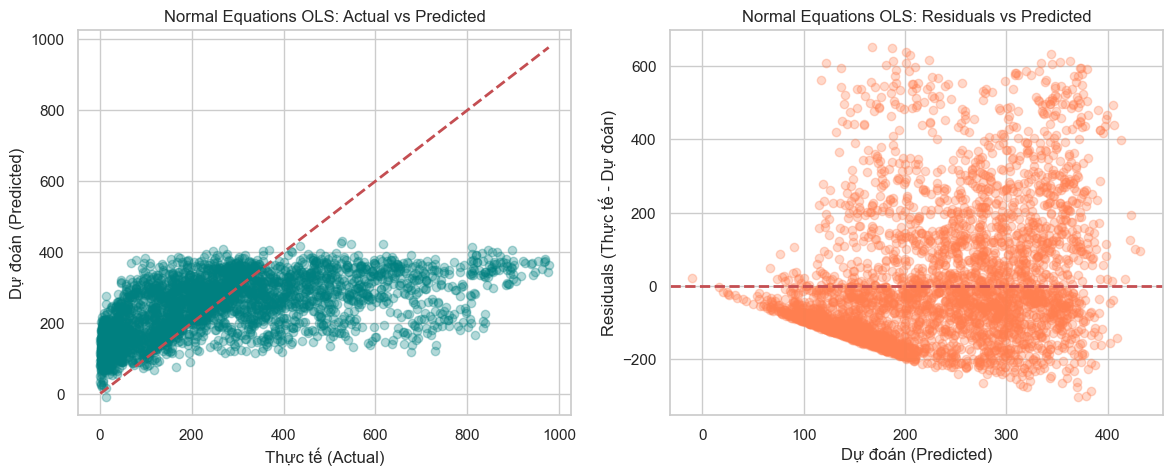

In [ ]:
def fit_pred_ols(X_tr, y_tr, X_val):
    w = np.linalg.pinv(X_tr.T.dot(X_tr)).dot(X_tr.T).dot(y_tr)
    return X_val.dot(w), w


model_ols = evaluate_model(
    "Normal Equations OLS",
    fit_pred_ols,
    X_train_b,
    y_train,
    X_test_b,
    y_test,
    X_val_b,
    y_val,
)

#### So sánh với Sklearn LinearRegression
Chạy mô hình hàm chuẩn `LinearRegression` của thư viện Sklearn để đối chiếu tính chính xác của thuật toán (Numpy) mà chúng ta tự cài.

[Sklearn Linear Regression] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 17711.93 ± 9423.90
  - CV_RMSE (Mean ± Std): 128.49 ± 34.69
  - CV_MAE (Mean ± Std): 99.67 ± 29.57
  - CV_R2 (Mean ± Std): 0.1664 ± 0.2959
  - Val MSE: 33622.1540
  - Val RMSE: 183.3634
  - Val MAE: 148.9251
  - Val R2: 0.2983
  - Test MSE: 33590.7693
  - Test RMSE: 183.2778
  - Test MAE: 138.2918
  - Test R2: 0.3090


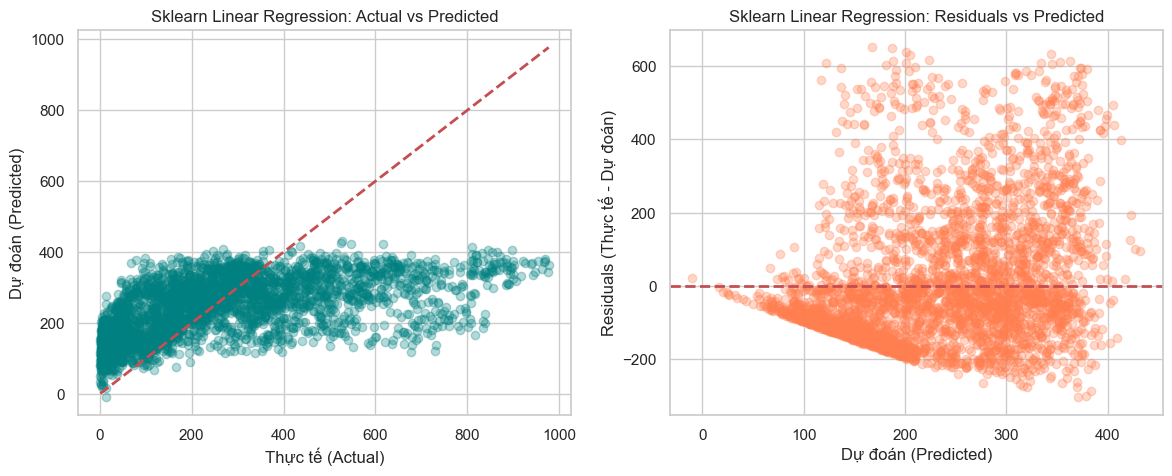

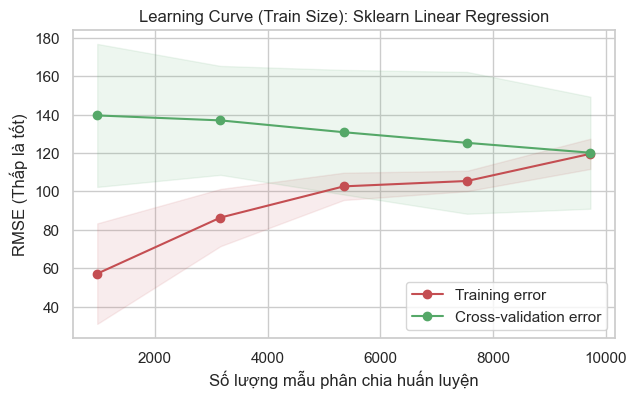


SO SÁNH NUMPY OLS VÀ SKLEARN LINEAR REGRESSION
Chênh lệch dự đoán lớn nhất (Max Pred Diff): 4.7634785005e-11
Chênh lệch trọng số lớn nhất (Max Weight Diff): 6.0481397668e-11
=> KẾT LUẬN: Cài đặt OLS thủ công bằng Numpy khớp hoàn toàn với Sklearn!


In [3]:
from sklearn.linear_model import LinearRegression

preds_dict = load_registry()["preds_dict"]


def fit_pred_sk_ols(X_tr, y_tr, X_val):
    model = LinearRegression(fit_intercept=False)
    model.fit(X_tr, y_tr)
    return model.predict(X_val), model


model_sk_ols = evaluate_model(
    "Sklearn Linear Regression",
    fit_pred_sk_ols,
    X_train_b,
    y_train,
    X_test_b,
    y_test,
    X_val_b,
    y_val,
)

plot_sklearn_learning_curve_wrapper(
    LinearRegression(fit_intercept=False),
    "Sklearn Linear Regression",
    X_train_b,
    y_train,
)

print("\n" + "=" * 50)
print("SO SÁNH NUMPY OLS VÀ SKLEARN LINEAR REGRESSION")
print("=" * 50)

max_pred_diff = np.max(
    np.abs(preds_dict["Normal Equations OLS"] - preds_dict["Sklearn Linear Regression"])
)
w_sk = model_sk_ols.coef_
# model_ols (Numpy) trả về ma trận (hoặc vector) weights
max_weight_diff = np.max(np.abs(model_ols - w_sk))

print(f"Chênh lệch dự đoán lớn nhất (Max Pred Diff): {max_pred_diff:.10e}")
print(f"Chênh lệch trọng số lớn nhất (Max Weight Diff): {max_weight_diff:.10e}")

if np.allclose(
    preds_dict["Normal Equations OLS"],
    preds_dict["Sklearn Linear Regression"],
    atol=1e-5,
):
    print("=> KẾT LUẬN: Cài đặt OLS thủ công bằng Numpy khớp hoàn toàn với Sklearn!")
else:
    print("=> KẾT LUẬN: Có biểu hiện sai lệch giữa Numpy và Sklearn.")

### 1.1.1 Kiểm tra giả định Gauss-Markov
Kiểm tra QQ-plot xác định phân phối chuẩn và Breusch-Pagan test kiểm tra Heteroscedasticity.

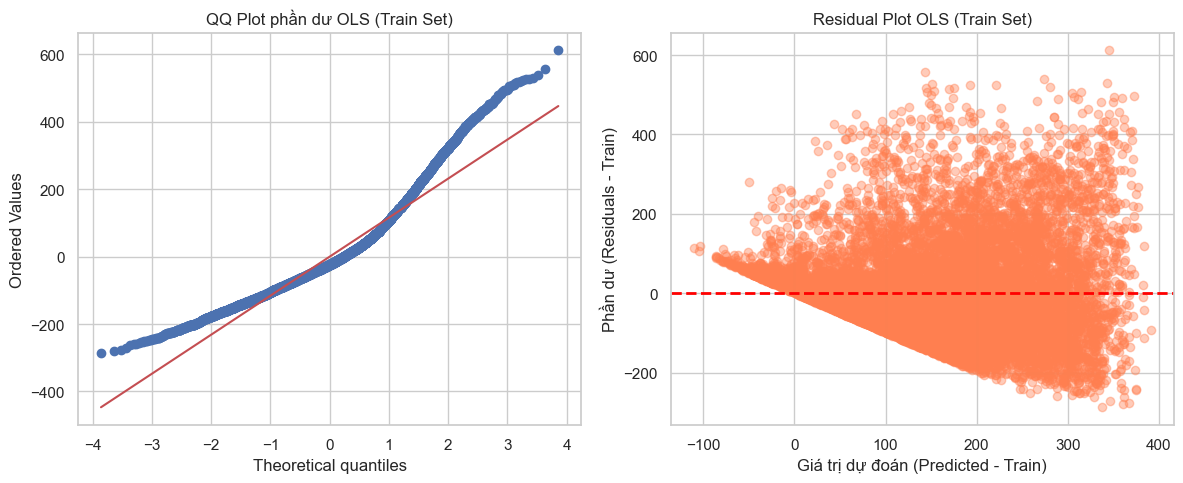

Breusch-Pagan Test (Train): LM Stat = 1093.4954, p-value = 1.4596e-226
Có hiện tượng heteroscedasticity (phương sai sai số thay đổi). Nên dùng WLS.


In [4]:
y_train_pred_ols, _ = fit_pred_ols(X_train_b, y_train, X_train_b)
residuals_train_ols = y_train - y_train_pred_ols

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Kiểm tra tính chuẩn (Normality) qua QQ-Plot trên Train
stats.probplot(residuals_train_ols, dist="norm", plot=axes[0])
axes[0].set_title("QQ Plot phần dư OLS (Train Set)")

# 2. Kiểm tra phương sai sai số không đổi (Homoscedasticity) qua Residual Plot trên Train
axes[1].scatter(y_train_pred_ols, residuals_train_ols, alpha=0.4, color="coral")
axes[1].axhline(y=0, color="red", linestyle="--", lw=2)
axes[1].set_xlabel("Giá trị dự đoán (Predicted - Train)")
axes[1].set_ylabel("Phần dư (Residuals - Train)")
axes[1].set_title("Residual Plot OLS (Train Set)")

plt.tight_layout()
plt.show()


def breusch_pagan_test(X, residuals):
    squared_residuals = residuals**2
    w_bp = np.linalg.pinv(X.T.dot(X)).dot(X.T).dot(squared_residuals)
    pred_squared_residuals = X.dot(w_bp)

    ss_res = np.sum((squared_residuals - pred_squared_residuals) ** 2)
    ss_tot = np.sum((squared_residuals - np.mean(squared_residuals)) ** 2)
    r2_bp = 1 - (ss_res / ss_tot)

    n = X.shape[0]
    p = X.shape[1] - 1
    lm_stat = n * r2_bp
    p_value = stats.chi2.sf(lm_stat, p)
    return lm_stat, p_value


bp_stat, bp_pval = breusch_pagan_test(X_train_b, residuals_train_ols)
print(f"Breusch-Pagan Test (Train): LM Stat = {bp_stat:.4f}, p-value = {bp_pval:.4e}")
if bp_pval < 0.05:
    print(
        "Có hiện tượng heteroscedasticity (phương sai sai số thay đổi). Nên dùng WLS."
    )
else:
    print("Không có hiện tượng heteroscedasticity.")

### 1.2 Mini-batch Gradient Descent
Biểu đồ Learning curve của hệ thống huấn luyện lặp theo kỉ nguyên

[Mini-Batch GD] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 17669.01 ± 9478.70
  - CV_RMSE (Mean ± Std): 128.25 ± 34.94
  - CV_MAE (Mean ± Std): 99.60 ± 29.75
  - CV_R2 (Mean ± Std): 0.1715 ± 0.2909
  - Val MSE: 33663.0489
  - Val RMSE: 183.4749
  - Val MAE: 149.2077
  - Val R2: 0.2975
  - Test MSE: 33645.6517
  - Test RMSE: 183.4275
  - Test MAE: 138.5376
  - Test R2: 0.3079


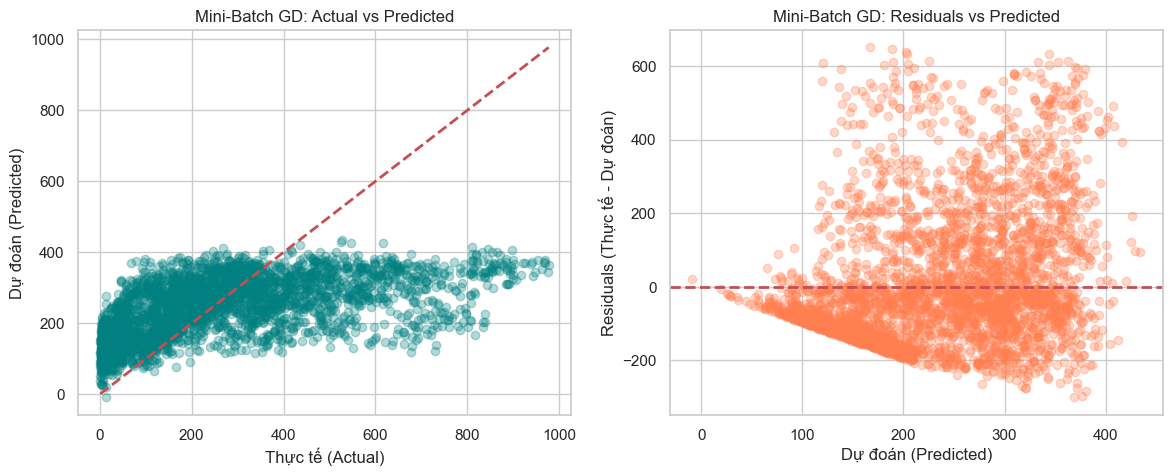

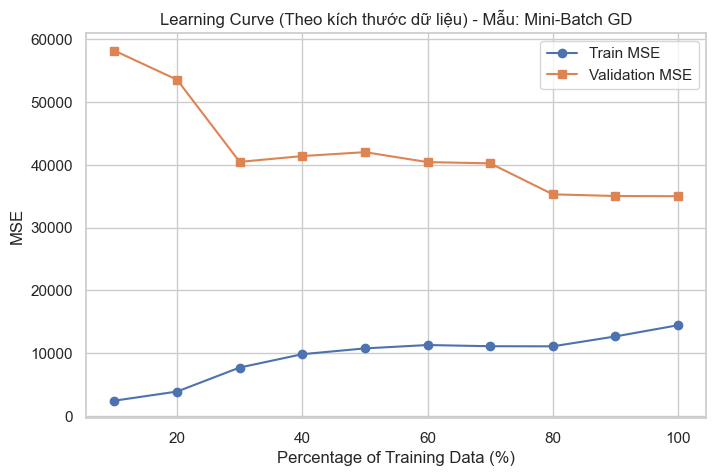

In [5]:
def minibatch_gd(X, y, epochs=100, batch_size=128, lr_init=0.01):
    m, n_features = X.shape
    np.random.seed(42)
    w = np.random.randn(n_features) * 0.01
    losses = []

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        lr = lr_init * 0.5 * (1 + np.cos(np.pi * epoch / epochs))

        epoch_loss = 0
        for i in range(0, m, batch_size):
            X_i = X_shuffled[i : i + batch_size]
            y_i = y_shuffled[i : i + batch_size]

            predictions = X_i.dot(w)
            error = predictions - y_i
            epoch_loss += np.sum(error**2)

            gradient = (1 / batch_size) * X_i.T.dot(error)
            # Add gradient clipping to prevent exploding gradients (NaN)
            gradient = np.clip(gradient, -10000, 10000)
            w -= lr * gradient

        losses.append(epoch_loss / m)

    return w, losses


X_train_scaled_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_val_scaled_b = np.c_[np.ones((X_val_scaled.shape[0], 1)), X_val_scaled]
X_test_scaled_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

# Lấy w_gd dùng sau nếu cần (hoặc chỉ quan sát quá trình chạy cơ bản)
w_gd, _ = minibatch_gd(
    X_train_scaled_b, y_train, epochs=200, batch_size=128, lr_init=0.01
)


def fit_pred_gd(X_tr, y_tr, X_val):
    w, _ = minibatch_gd(X_tr, y_tr, epochs=200, batch_size=128, lr_init=0.01)
    return X_val.dot(w), w


_ = evaluate_model(
    "Mini-Batch GD",
    fit_pred_gd,
    X_train_scaled_b,
    y_train,
    X_test_scaled_b,
    y_test,
    X_val_scaled_b,
    y_val,
)

plot_learning_curve_data_size(
    "Mini-Batch GD", fit_pred_gd, X_train_scaled_b, y_train, X_val_scaled_b, y_val
)

### So sánh thời gian hội tụ (Training Time) giữa OLS và Mini-Batch GD
Đo lường tốc độ thực thi thuần tuý của công thức đại số tuyến tính so với vòng lặp tối ưu Gradient Descent.

SO SÁNH THỜI GIAN HUẤN LUYỆN (OLS vs Mini-Batch GD)
Thời gian OLS (Normal Equations): 0.00255 giây
Thời gian Mini-Batch GD (200 epochs): 0.82463 giây
=> OLS hội tụ nhanh hơn 323.60 lần so với Mini-Batch GD trên tập dữ liệu này.


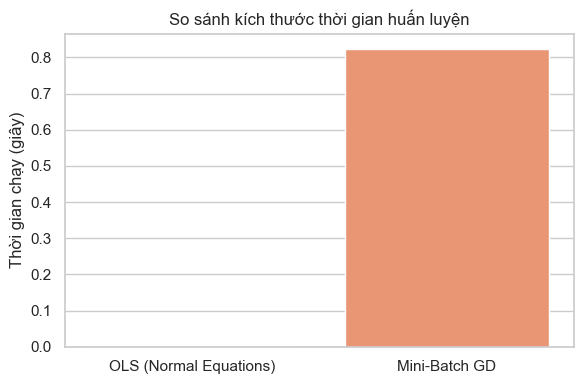

In [6]:

# 1. Đo thời gian Normal Equations (OLS)
start_ols = time.process_time()
_ = np.linalg.pinv(X_train_b.T.dot(X_train_b)).dot(X_train_b.T).dot(y_train)
time_ols = time.process_time() - start_ols

# 2. Đo thời gian Mini-Batch Gradient Descent
start_gd = time.process_time()
_, _ = minibatch_gd(X_train_scaled_b, y_train, epochs=200, batch_size=128, lr_init=0.01)
time_gd = time.process_time() - start_gd

print("=" * 60)
print("SO SÁNH THỜI GIAN HUẤN LUYỆN (OLS vs Mini-Batch GD)")
print("=" * 60)
print(f"Thời gian OLS (Normal Equations): {time_ols:.5f} giây")
print(f"Thời gian Mini-Batch GD (200 epochs): {time_gd:.5f} giây")

if time_ols < time_gd:
    print(
        f"=> OLS hội tụ nhanh hơn {time_gd / time_ols:.2f} lần so với Mini-Batch GD trên tập dữ liệu này."
    )
else:
    print(f"=> Mini-Batch GD hội tụ nhanh hơn {time_ols / time_gd:.2f} lần so với OLS.")

# Vẽ biểu đồ cột để minh hoạ trực quan
plt.figure(figsize=(6, 4))
sns.barplot(
    x=["OLS (Normal Equations)", "Mini-Batch GD"], y=[time_ols, time_gd], palette="Set2"
)
plt.ylabel("Thời gian chạy (giây)")
plt.title("So sánh kích thước thời gian huấn luyện")
plt.tight_layout()
plt.show()

### 1.3 WLS (Feasible Generalized Least Squares)

[WLS] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 18057.53 ± 10290.89
  - CV_RMSE (Mean ± Std): 129.06 ± 37.41
  - CV_MAE (Mean ± Std): 98.75 ± 28.82
  - CV_R2 (Mean ± Std): 0.1740 ± 0.2686
  - Val MSE: 35453.4562
  - Val RMSE: 188.2909
  - Val MAE: 146.3070
  - Val R2: 0.2601
  - Test MSE: 36415.9856
  - Test RMSE: 190.8297
  - Test MAE: 139.0330
  - Test R2: 0.2509


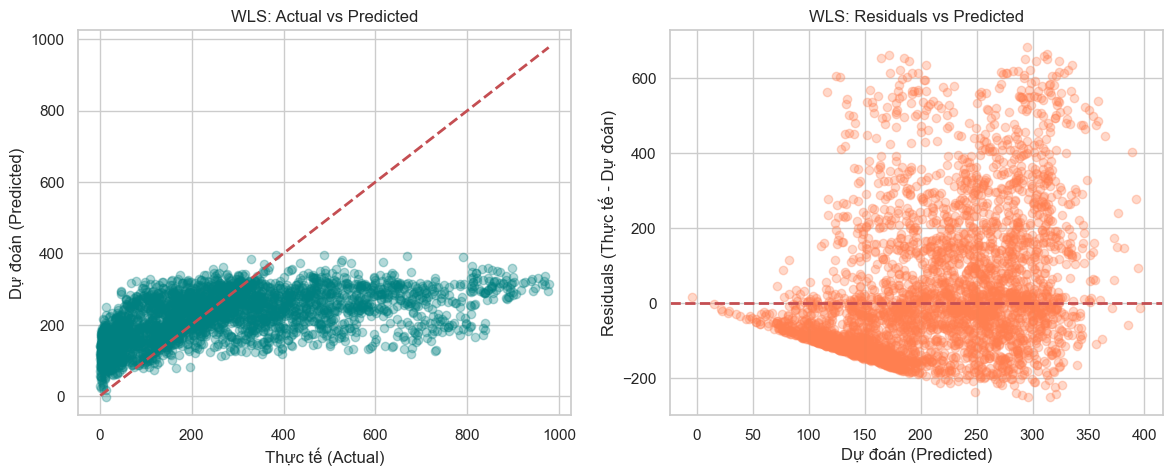

In [7]:
def fit_pred_wls(X_tr, y_tr, X_val):
    # Bước 1: Fit OLS thông thường
    w_ols = np.linalg.pinv(X_tr.T.dot(X_tr)).dot(X_tr.T).dot(y_tr)
    y_pred_tr = X_tr.dot(w_ols)
    residuals_abs = np.abs(y_tr - y_pred_tr)

    # Bước 2: Hồi quy phần dư tuyệt đối theo X để dự đoán phương sai phân phối tại từng điểm (Auxiliary FGLS)
    w_aux = np.linalg.pinv(X_tr.T.dot(X_tr)).dot(X_tr.T).dot(residuals_abs)
    volatility_est = X_tr.dot(w_aux)

    # Cắt các giá trị dự đoán rủi ro âm/gần 0
    volatility_est = np.clip(volatility_est, a_min=1e-5, a_max=None)

    # Bước 3: Tạo trọng số W = 1 / Var = 1 / (volatility_est^2)
    weights_tr = 1.0 / (volatility_est**2)

    # Bước 4: Fit WLS sử dụng nhân vector thay vì sinh ma trận đường chéo khổng lồ
    XTw_X = (X_tr * weights_tr[:, None]).T.dot(X_tr)
    XTw_y = (X_tr * weights_tr[:, None]).T.dot(y_tr)
    w_wls = np.linalg.pinv(XTw_X).dot(XTw_y)

    return X_val.dot(w_wls), w_wls


_ = evaluate_model(
    "WLS", fit_pred_wls, X_train_b, y_train, X_test_b, y_test, X_val_b, y_val
)